In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Example entries from the dataset

In [ ]:
from datasets import Dataset, DatasetDict, load_dataset
from pathlib import Path
from tqdm import tqdm

In [ ]:

# Path to your downloaded data folder
DATA_DIR = Path("/content/drive/MyDrive/96517/data")

In [ ]:

# load src/tgt files locally with progress
train_src = load_dataset("text", data_files={"train": str(DATA_DIR / "train.src.cleaned")}, split="train")
train_tgt = load_dataset("text", data_files={"train": str(DATA_DIR / "train.tgt")}, split="train")

val_src = load_dataset("text", data_files={"val": str(DATA_DIR / "val.src.cleaned")}, split="val")
val_tgt = load_dataset("text", data_files={"val": str(DATA_DIR / "val.tgt")}, split="val")

test_src = load_dataset("text", data_files={"test": str(DATA_DIR / "test.src.cleaned")}, split="test")
test_tgt = load_dataset("text", data_files={"test": str(DATA_DIR / "test.tgt")}, split="test")


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
# merge into pairs with tqdm
def merge(src, tgt):
    docs = []
    sums = []
    for s, t in tqdm(zip(src["text"], tgt["text"]), total=len(src), desc="Merging"):
        docs.append(s)
        sums.append(t)
    return Dataset.from_dict({"document": docs, "summary": sums})


In [ ]:
train_ds = merge(train_src, train_tgt)
val_ds = merge(val_src, val_tgt)
test_ds = merge(test_src, test_tgt)

Merging: 100%|██████████| 5622/5622 [00:00<00:00, 13084.52it/s]


In [ ]:
# bundle into DatasetDict
dataset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['document', 'summary'],
        num_rows: 44972
    })
    validation: Dataset({
        features: ['document', 'summary'],
        num_rows: 5622
    })
    test: Dataset({
        features: ['document', 'summary'],
        num_rows: 5622
    })
})


In [ ]:

print("\n--- Sample fields ---")
print(dataset["train"][0])  # sample pair



--- Sample fields ---
{'document': 'National Archives NEWLINE_CHAR NEWLINE_CHAR Yes, it’s that time again, folks. It’s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs. NEWLINE_CHAR NEWLINE_CHAR A fresh update on the U.S. employment situation for January hits the wires at 8:30 a.m. New York time offering one of the most important snapshots on how the economy fared during the previous month. Expectations are for 203,000 new jobs to be created, according to economists polled by Dow Jones Newswires, compared to 227,000 jobs added in February. The unemployment rate is expected to hold steady at 8.3%. NEWLINE_CHAR NEWLINE_CHAR Here at MarketBeat HQ, we’ll be offering color commentary before and after the data crosses the wires. Feel free to weigh-in yourself, via the comments section. And while you’re here, why don’t you sign up to follow us on Twitter. NEWLINE_CHAR NEWLINE_CHAR Enjo

# PreProcess the dataset

In [ ]:
!pip -q install datasets nltk spacy

In [ ]:
# Try to get the small English model (safe if already installed)
import subprocess, sys
try:
    import spacy
    spacy.load("en_core_web_sm")
except Exception:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=False)

In [ ]:
import re, os
from datasets import load_dataset, DatasetDict
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab") # Added to download the missing resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
# Try spaCy; fall back to NLTK if spaCy isn't available
use_spacy = False
try:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
    use_spacy = True
except Exception:
    nlp = None
    use_spacy = False

In [ ]:
def clean_text(text: str) -> str:
    """Remove NEWLINE_CHAR, HTML tags, and extra whitespace."""
    text = text.replace("NEWLINE_CHAR", "\n")
    text = re.sub(r"<.*?>", " ", text)        # strip HTML
    text = re.sub(r"\s+", " ", text).strip()  # collapse spaces
    return text

In [ ]:
def split_cluster_into_docs(cluster_text: str):
    """Split Multi-News cluster string into individual documents."""
    docs = [d.strip() for d in cluster_text.split("|||||") if d.strip()]
    return docs

In [ ]:
def preprocess_one_document(doc_text: str):
    """Sentence split, tokenize, lemmatize, stopword-filter a single document."""
    # light cleanup for sentence splitting/tokenization
    doc_text = re.sub(r"[^\x00-\x7F]+", " ", doc_text)  # drop non-ascii safely
    doc_text = re.sub(r"\s+", " ", doc_text).strip()

    sentences = sent_tokenize(doc_text)
    tokens_per_sentence = []

    for s in sentences:
        # raw word tokens; keep alphabetic only
        words = [w for w in word_tokenize(s) if w.isalpha()]

        if use_spacy:
            # better lemmatization with spaCy
            sp = nlp(" ".join(words).lower())
            lemmas = [t.lemma_ for t in sp if t.is_alpha and t.lemma_ not in STOPWORDS]
        else:
            # fallback lemmatization with NLTK
            lemmas = [lemmatizer.lemmatize(w.lower()) for w in words if w.lower() not in STOPWORDS]

        tokens_per_sentence.append(lemmas)

    return {"sentences": sentences, "tokens": tokens_per_sentence}


In [ ]:

def preprocess_example(example):
    """
    Takes one Multi-News example:
      - example['document']: concatenated docs with '|||||'
      - example['summary']: reference summary
    Returns new fields to be appended to the dataset.
    """
    # Clean original fields
    doc_clean = clean_text(example["document"])
    summary_clean = clean_text(example["summary"])

    # Split into individual docs
    docs = split_cluster_into_docs(doc_clean)

    # Preprocess each doc
    processed_docs = [preprocess_one_document(d) for d in docs]

    return {
        "docs": docs,                                        # list[str]
        "sentences": [p["sentences"] for p in processed_docs],  # list[list[str]]
        "tokens": [p["tokens"] for p in processed_docs],        # list[list[list[str]]]
        "summary_clean": summary_clean
    }



In [ ]:
workset = dataset

NUM_PROC = 1

processed = workset.map(
    preprocess_example,
    desc="Preprocessing Multi-News (clean/split/sentences/tokens)",
    num_proc=NUM_PROC
)
print(processed)


Preprocessing Multi-News (clean/split/sentences/tokens):   0%|          | 0/44972 [00:00<?, ? examples/s]

Preprocessing Multi-News (clean/split/sentences/tokens):   0%|          | 0/5622 [00:00<?, ? examples/s]

Preprocessing Multi-News (clean/split/sentences/tokens):   0%|          | 0/5622 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 44972
    })
    validation: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 5622
    })
    test: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 5622
    })
})


# Inspect a sample

In [ ]:
ex = processed["train"][0]
print("\n--- Sample fields ---")
print("Docs in cluster:", len(ex["docs"]))
print("First doc first 2 sentences:", ex["sentences"][0][:2])
print("First sentence tokens (first doc):", ex["tokens"][0][0][:25])
print("Summary (clean):", ex["summary_clean"][:200], "...")



--- Sample fields ---
Docs in cluster: 2
First doc first 2 sentences: ['National Archives Yes, it s that time again, folks.', 'It s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs.']
First sentence tokens (first doc): ['national', 'archive', 'yes', 'time', 'folk']
Summary (clean): – The unemployment rate dropped to 8.2% last month, but the economy only added 120,000 jobs, when 203,000 new jobs had been predicted, according to today's jobs report. Reaction on the Wall Street Jou ...


In [ ]:

# This creates a folder you can reload with `datasets.load_from_disk(path)`
out_dir = "/content/drive/MyDrive/96517/processed"
processed.save_to_disk(out_dir)
print(f"\nSaved processed dataset to: {out_dir}")

Saving the dataset (0/5 shards):   0%|          | 0/44972 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5622 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5622 [00:00<?, ? examples/s]


Saved processed dataset to: ./processed


# Load the processed dataset

In [ ]:
pip install datasets

In [ ]:
from datasets import load_from_disk
import random

# Load the processed dataset
processed = load_from_disk("/content/drive/MyDrive/96517/processed")
print(processed)


DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 44972
    })
    validation: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 5622
    })
    test: Dataset({
        features: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean'],
        num_rows: 5622
    })
})


In [ ]:
# Check available columns
print("\nFeatures in one example:", processed["train"].column_names)


Features in one example: ['document', 'summary', 'docs', 'sentences', 'tokens', 'summary_clean']


In [ ]:
# Inspect a random training sample
sample = processed["train"][118]

print("\n--- Sample Document Cluster ---")
print("Number of docs in cluster:", len(sample["docs"]))
print("First doc (first 2 sentences):", sample["sentences"][0][:2])
print("First doc (tokens first 10):", sample["tokens"][0][:10])

print("\n--- Reference Summary ---")
print(sample["summary_clean"])



--- Sample Document Cluster ---
Number of docs in cluster: 4
First doc (first 2 sentences): ['Children working on tobacco farms in the United States are exposed to nicotine, toxic pesticides, and other dangers, Human Rights Watch said in a report released today.', 'While US law prohibits the sale of tobacco products to children, children can legally work on tobacco farms in the US.']
First doc (tokens first 10): [['child', 'work', 'tobacco', 'farm', 'united', 'states', 'expose', 'nicotine', 'toxic', 'pesticide', 'danger', 'human', 'right', 'watch', 'say', 'report', 'release', 'today'], ['law', 'prohibit', 'sale', 'tobacco', 'product', 'child', 'child', 'legally', 'work', 'tobacco', 'farm', 'us'], ['world', 'large', 'tobacco', 'company', 'buy', 'tobacco', 'grow', 'us', 'farm', 'none', 'child', 'labor', 'policy', 'sufficiently', 'protect', 'child', 'hazardous', 'work'], ['report', 'tobacco', 'hide', 'child', 'hazardous', 'child', 'labor', 'tobacco', 'farming', 'document', 'condition', '

# **info extra**

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize, ne_chunk
from nltk.tree import Tree

In [ ]:
resources = ["punkt", "punkt_tab", "maxent_ne_chunker", "words", "averaged_perceptron_tagger","maxent_ne_chunker_tab","averaged_perceptron_tagger_eng"]
for r in resources:
    nltk.download(r)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
import os
import csv
import sys
import time
import json
import re
from tqdm import tqdm
from datasets import load_from_disk, concatenate_datasets
from transformers import pipeline
import spacy
from typing import List, Tuple

In [ ]:
csv.field_size_limit(sys.maxsize)
PROCESS_MODE = "low"    # options: "full", "half", "quat", "low"
BATCH_SIZE = 32       # batch size for NER
NUM_CHUNKS = 5
OUTPUT_DIR = "/content/drive/MyDrive/96517/chunk_outputs"
FINAL_CSV = "/content/drive/MyDrive/96517/info_extracted.csv"


In [ ]:
print("[INFO] Loading models...")

# NER
ner_pipe = pipeline("ner", model="dslim/bert-base-NER",
                    aggregation_strategy="simple", device=0)

# Relation Extraction (Babelscape ReBEL)
RE_MODEL = "Babelscape/rebel-large"
re_pipe = pipeline("text2text-generation", model=RE_MODEL, device=0)

# Coref + spaCy fallback SVO
nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])


[INFO] Loading models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/344 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
def extract_entities_batch(texts):
    outputs = ner_pipe(texts, batch_size=BATCH_SIZE)
    all_entities = []
    for out in outputs:
        ents = [(item["word"], item["entity_group"]) for item in out]
        all_entities.append(ents)
    return all_entities

In [ ]:
def extract_svo_from_text(text: str) -> List[Tuple[str, str, str]]:
    doc = nlp(text)
    rels = []
    for sent in doc.sents:
        subj, obj, verb = None, None, None
        for token in sent:
            if "subj" in token.dep_:
                subj = token.text
            if "obj" in token.dep_:
                obj = token.text
            if token.pos_ == "VERB" and verb is None:
                verb = token.lemma_
        if subj and verb and obj:
            rels.append((subj, verb, obj))
    return rels


In [ ]:
def parse_rebel_text(text_out: str) -> List[Tuple[str, str, str]]:
    if not text_out or not text_out.strip():
        return []

    triples = []

    try:
        parsed = json.loads(text_out)
        if isinstance(parsed, list):
            for item in parsed:
                if isinstance(item, (list, tuple)) and len(item) >= 3:
                    triples.append((str(item[0]).strip(), str(item[1]).strip(), str(item[2]).strip()))
            if triples:
                return triples
    except Exception:
        pass

    pattern = re.compile(r"<triplet>\s*(.*?)\s*<subj>\s*(.*?)\s*<obj>\s*(.*?)(?=(?:<triplet>|$))", flags=re.DOTALL)
    matches = pattern.findall(text_out)
    if matches:
        for subj, rel, obj in matches:
            triples.append((subj.strip(), rel.strip(), obj.strip()))
        if triples:
            return triples

    matches = re.findall(r"\(\s*([^,()]+)\s*,\s*([^,()]+)\s*,\s*([^,()]+)\s*\)", text_out)
    if matches:
        for subj, rel, obj in matches:
            triples.append((subj.strip(), rel.strip(), obj.strip()))
        if triples:
            return triples

    for sep in ["\t", " | ", " |", "| ", " - ", " : "]:
        lines = [l.strip() for l in text_out.splitlines() if l.strip()]
        for line in lines:
            if sep in line:
                parts = [p.strip() for p in line.split(sep)]
                if len(parts) >= 3:
                    triples.append((parts[0], parts[1], " ".join(parts[2:])))
        if triples:
            return triples

    tokens = text_out.split()
    subj = rel = obj = None
    mode = None
    for i, t in enumerate(tokens):
        tl = t.lower()
        if tl.startswith("<triplet>"):
            subj = rel = obj = None
            mode = "subj"
            continue
        if tl in ("<subj>", "<subject>"):
            mode = "subj"; continue
        if tl in ("<rel>", "<relation>"):
            mode = "rel"; continue
        if tl in ("<obj>", "<object>"):
            mode = "obj"; continue
        if mode == "subj":
            subj = (subj + " " + t) if subj else t
        elif mode == "rel":
            rel = (rel + " " + t) if rel else t
        elif mode == "obj":
            obj = (obj + " " + t) if obj else t
        if subj and rel and obj and (i == len(tokens)-1 or tokens[i+1].lower().startswith("<triplet>")):
            triples.append((subj.strip(), rel.strip(), obj.strip()))
            subj = rel = obj = None
            mode = None

    return triples



In [ ]:
def extract_relations_batch(texts: List[str], re_pipe, chunk_sentences: bool = True):
    results = []

    for text in texts:
        triples_for_doc = []

        if chunk_sentences and len(text) > 800:
            sents = [sent.text for sent in nlp(text).sents]
            for sent in sents:
                if not sent.strip():
                    continue
                try:
                    out = re_pipe(sent, max_length=256, truncation=True)
                except Exception:
                    out = None
                text_out = None
                if out:
                    first = out[0] if isinstance(out, list) else out
                    if isinstance(first, dict):
                        text_out = first.get("generated_text") or first.get("text")
                    elif isinstance(first, str):
                        text_out = first
                if text_out:
                    parsed = parse_rebel_text(text_out)
                    if parsed:
                        triples_for_doc.extend(parsed)
            if not triples_for_doc:
                triples_for_doc = extract_svo_from_text(text)
            results.append(triples_for_doc)
            continue

        try:
            out = re_pipe(text, max_length=512, truncation=True)
        except Exception:
            out = None

        text_out = None
        if out:
            first = out[0] if isinstance(out, list) else out
            if isinstance(first, dict):
                text_out = first.get("generated_text") or first.get("text")
            elif isinstance(first, str):
                text_out = first

        if text_out:
            parsed = parse_rebel_text(text_out)
            if parsed:
                results.append(parsed)
                continue

        results.append(extract_svo_from_text(text))

    return results


In [ ]:
def resolve_coref_batch(texts):
    resolved = []
    for text in texts:
        doc = nlp(text)
        r_text = text
        entities = [ent.text for ent in doc.ents if ent.label_ in ["PERSON", "ORG"]]
        if entities:
            main_entity = entities[0]
            for token in doc:
                if token.pos_ == "PRON" and token.text.lower() in ["he","she","they","him","her","it"]:
                    r_text = r_text.replace(token.text, main_entity)
        resolved.append(r_text)
    return resolved


In [ ]:
print("[INFO] Loading dataset...")
dataset = load_from_disk("/content/drive/MyDrive/96517/processed")
full_data = concatenate_datasets([
    dataset["train"].flatten_indices(),
    dataset["validation"].flatten_indices(),
    dataset["test"].flatten_indices()
])

if PROCESS_MODE == "half":
    full_data = full_data.select(range(len(full_data)//2))
    print(f"[INFO] Using HALF dataset: {len(full_data)} docs")
elif PROCESS_MODE == "quat":
    full_data = full_data.select(range(len(full_data)//4))
    print(f"[INFO] Using QUARTER dataset: {len(full_data)} docs")
elif PROCESS_MODE == "low":
    full_data = full_data.select(range(200))
    print(f"[INFO] Using Low dataset: {len(full_data)} docs")
else:
    print(f"[INFO] Using FULL dataset: {len(full_data)} docs")


[INFO] Loading dataset...
[INFO] Using Low dataset: 200 docs


In [ ]:
total_docs = len(full_data)
chunk_size = total_docs // NUM_CHUNKS
os.makedirs(OUTPUT_DIR, exist_ok=True)

for chunk_id in range(NUM_CHUNKS):
    start = chunk_id * chunk_size
    end = total_docs if chunk_id == NUM_CHUNKS-1 else (chunk_id+1)*chunk_size
    csv_path = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id}.csv")

    if os.path.exists(csv_path):
        print(f"[Skip] Chunk {chunk_id} already processed.")
        continue

    print(f"[INFO] Processing chunk {chunk_id} (docs {start}-{end})...")
    t0 = time.time()

    with open(csv_path, "w", newline="", encoding="utf-8") as fout:
        writer = csv.DictWriter(fout, fieldnames=["chunk_id","doc_id","document","entities","relations","resolved"])
        writer.writeheader()

        for batch_start in tqdm(range(start, end, BATCH_SIZE)):
            batch_end = min(batch_start+BATCH_SIZE, end)
            texts = [full_data[i]["document"] for i in range(batch_start, batch_end)]

            ents_batch = extract_entities_batch(texts)
            rels_batch = extract_relations_batch(texts, re_pipe)
            resolved_batch = resolve_coref_batch(texts)

            for idx, text in enumerate(texts):
                writer.writerow({
                    "chunk_id": chunk_id,
                    "doc_id": batch_start+idx,
                    "document": text,
                    "entities": json.dumps(ents_batch[idx]),
                    "relations": json.dumps(rels_batch[idx]),
                    "resolved": resolved_batch[idx]
                })

    print(f"[INFO] Saved chunk {chunk_id} → {csv_path} (Time: {(time.time()-t0)/60:.2f} min)")


[Skip] Chunk 0 already processed.
[Skip] Chunk 1 already processed.
[Skip] Chunk 2 already processed.
[Skip] Chunk 3 already processed.
[Skip] Chunk 4 already processed.


In [ ]:
print("[INFO] Merging all chunks...")
with open(FINAL_CSV, "w", newline="", encoding="utf-8") as fout:
    writer = None
    for chunk_id in range(NUM_CHUNKS):
        cp = os.path.join(OUTPUT_DIR, f"chunk_{chunk_id}.csv")
        if not os.path.exists(cp):
            continue
        with open(cp, "r", encoding="utf-8") as fin:
            rdr = csv.DictReader(fin)
            if writer is None:
                writer = csv.DictWriter(fout, fieldnames=rdr.fieldnames)
                writer.writeheader()
            for row in rdr:
                writer.writerow(row)

print(f"[INFO] Final merged file saved at: {FINAL_CSV}")


[INFO] Merging all chunks...
[INFO] Final merged file saved at: /content/drive/MyDrive/96517/info_extracted.csv


In [ ]:
import pandas as pd

final_csv = "/content/drive/MyDrive/96517/info_extracted.csv"

print("[INFO] Loading merged file...")
df = pd.read_csv(final_csv)

print(f"[INFO] Loaded {len(df)} rows with columns: {list(df.columns)}\n")
print(df['relations'].head(10))
print(df['relations'].apply(type).value_counts())
print(df['relations'].explode().head(10))

print("[SAMPLE ROWS]")
print(df.sample(5).to_string(index=False))

sample_idx = 0
print("\n[DETAILED SAMPLE ROW]")
print(df.iloc[sample_idx].to_dict())


[INFO] Loading merged file...
[INFO] Loaded 150 rows with columns: ['chunk_id', 'doc_id', 'document', 'entities', 'relations', 'resolved']

0    [["interests", "\u2019", "thing"], ["update", ...
1    [["she", "ban", "Sterling"], ["Prev", "click",...
2    [["authorities", "crash", "board"], ["Piringer...
3    [["site", "expose", "mine"], ["which", "expose...
4    [["man", "accuse", "charges"], ["Matthews", "a...
5    [["hotlines", "provide", "24/7"], ["you", "exp...
6    [["Hosts", "apologise", "symbol"], ["symbol", ...
7    [["which", "upload", "Machine"], ["they", "kee...
8    [["Energy", "operate", "Church"], ["homes", "h...
9    [["check", "be", "woman"], ["he", "report", "w...
Name: relations, dtype: object
relations
<class 'str'>    150
Name: count, dtype: int64
0    [["interests", "\u2019", "thing"], ["update", ...
1    [["she", "ban", "Sterling"], ["Prev", "click",...
2    [["authorities", "crash", "board"], ["Piringer...
3    [["site", "expose", "mine"], ["which", "expose...
4 

# KG

In [ ]:
import os
import pandas as pd
import networkx as nx
import ast
from collections import defaultdict
import numpy as np
import math

# Semantic + Contextual models
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer

# Load sentence embedding model
sem_model = SentenceTransformer("all-MiniLM-L6-v2")

# Ensure spaCy is loaded for NER
use_spacy = False
try:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["parser", "textcat"])  # Keep NER
    use_spacy = True
except Exception:
    nlp = None
    use_spacy = False
    print("Warning: spaCy not loaded. NER will be skipped in KG building.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def safe_text(value):
    if value is None:
        return ""
    if isinstance(value, float):
        if math.isnan(value):
            return ""
        return str(value)
    return str(value)

In [ ]:
def extract_entities(text):
    """Extract entities using spaCy NER."""
    text = safe_text(text) # Ensure text is a string
    if not text.strip():
        return []
    if nlp and use_spacy:
        doc = nlp(text)
        return [(ent.text, ent.label_) for ent in doc.ents]
    return []

In [ ]:
def normalize_entity(ent: str) -> str:
    """Normalize entity string for deduplication."""
    return ent.strip().lower()



In [ ]:
def compute_relation_score(subj, rel, obj, context, frequency=1):
    """Compute a composite score for (subj, rel, obj)."""
    try:
        # 1) Semantic relevance
        emb_subj = sem_model.encode(subj, convert_to_tensor=True)
        emb_obj = sem_model.encode(obj, convert_to_tensor=True)
        semantic_score = float(util.cos_sim(emb_subj, emb_obj))

        # 2) Contextual importance via TF-IDF
        tfidf = TfidfVectorizer(stop_words="english")
        tfidf_matrix = tfidf.fit_transform([context])
        tfidf_score = tfidf_matrix.max() if tfidf_matrix.nnz else 0.0

        # 3) Frequency weight (log scaling)
        freq_score = np.log1p(frequency)

        # Weighted sum (tunable α, β, γ)
        final_score = (0.4 * freq_score) + (0.4 * semantic_score) + (0.2 * tfidf_score)
        return round(final_score, 4)
    except Exception:
        return 0.0



In [ ]:
def build_enhanced_knowledge_graph(info_file, output_graphml, output_gexf=None):

    # Load info extracted file
    df = pd.read_csv(info_file)

    # Ensure relations column is list type
    df["relations"] = df["relations"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    KG = nx.DiGraph()
    self_loops_skipped = 0  # Counter for skipped loops

    for index, row in df.iterrows():
        doc_id = row["doc_id"]
        text = row["document"]

        # Entities
        entities = extract_entities(text)
        for ent, label in entities:
            ent_norm = normalize_entity(ent)
            if not KG.has_node(ent_norm):
                KG.add_node(ent_norm, label=label if label else "Unknown", original_name=ent)

        # Relations
        relations = row["relations"]
        if isinstance(relations, list):
            for rel in relations:
                if isinstance(rel, (list, tuple)) and len(rel) == 3:
                    subj, verb, obj = rel
                    subj_norm = normalize_entity(subj)
                    obj_norm = normalize_entity(obj)

                    # Skip self-loops
                    if subj_norm == obj_norm:
                        self_loops_skipped += 1
                        continue

                    if not KG.has_node(subj_norm):
                        subj_label = next((label for e, label in entities if normalize_entity(e) == subj_norm), "Unknown")
                        KG.add_node(subj_norm, label=subj_label, original_name=subj)

                    if not KG.has_node(obj_norm):
                        obj_label = next((label for e, label in entities if normalize_entity(e) == obj_norm), "Unknown")
                        KG.add_node(obj_norm, label=obj_label, original_name=obj)

                    # Compute relation score
                    new_score = compute_relation_score(
                        safe_text(subj), safe_text(verb), safe_text(obj), safe_text(text), frequency=1
                    )

                    if KG.has_edge(subj_norm, obj_norm):
                        KG[subj_norm][obj_norm]["weight"] += 1
                        KG[subj_norm][obj_norm]["documents"].append(doc_id)
                        KG[subj_norm][obj_norm]["score"] = max(
                            KG[subj_norm][obj_norm].get("score", 0), new_score
                        )
                    else:
                        KG.add_edge(
                            subj_norm,
                            obj_norm,
                            relation=verb,
                            weight=1,
                            documents=[doc_id],
                            score=new_score,
                        )

    # Convert list of documents to string for GraphML compatibility
    for u, v, d in KG.edges(data=True):
        if "documents" in d and isinstance(d["documents"], list):
            d["documents"] = ",".join(map(str, d["documents"]))

    # Save outputs
    nx.write_graphml(KG, output_graphml)
    if output_gexf:
        nx.write_gexf(KG, output_gexf)

    print(f"[INFO] Enhanced Knowledge Graph saved to {output_graphml}")
    print(f"[INFO] Graph has {KG.number_of_nodes()} nodes and {KG.number_of_edges()} edges")
    print(f"[INFO] Skipped {self_loops_skipped} self-loops")

    return KG

In [ ]:
info_file = "/content/drive/MyDrive/96517/info_extracted.csv"
output_graphml = "/content/drive/MyDrive/96517/knowledge_graph_enhanced.graphml"
output_gexf = "/content/drive/MyDrive/96517/knowledge_graph_enhanced.gexf"

if os.path.exists(info_file):
    KG = build_enhanced_knowledge_graph(info_file, output_graphml, output_gexf)

    print("\n[INFO] Sample edges with weights, provenance & score:")
    for u, v, d in list(KG.edges(data=True))[:10]:
        print(f"{u} --({d.get('relation','N/A')}, w={d.get('weight',0)}, s={d.get('score',0)})--> {v}, docs={d.get('documents', '')[:50]}")
else:
    print(f"Error: Input file not found at {info_file}")

[INFO] Enhanced Knowledge Graph saved to /content/drive/MyDrive/96517/knowledge_graph_enhanced.graphml
[INFO] Graph has 12603 nodes and 8693 edges
[INFO] Skipped 34 self-loops

[INFO] Sample edges with weights, provenance & score:
first --(be, w=1, s=0.5169)--> april, docs=59
one --(identify, w=1, s=0.575)--> decisions, docs=2
one --(catapult, w=1, s=0.5335)--> ntsb, docs=2
one --(expect, w=1, s=0.5674)--> hunt, docs=6
one --(want, w=1, s=0.5692)--> platter, docs=6
one --(benefit, w=1, s=0.558)--> gaffe, docs=6
one --(accuse, w=1, s=0.5749)--> uncle, docs=24
one --(find, w=1, s=0.5674)--> trigger, docs=24
one --(study, w=1, s=0.5362)--> supremacists, docs=34
one --(depict, w=1, s=0.5601)--> masks, docs=34


[INFO] Loaded KG: 12603 nodes, 8693 edges


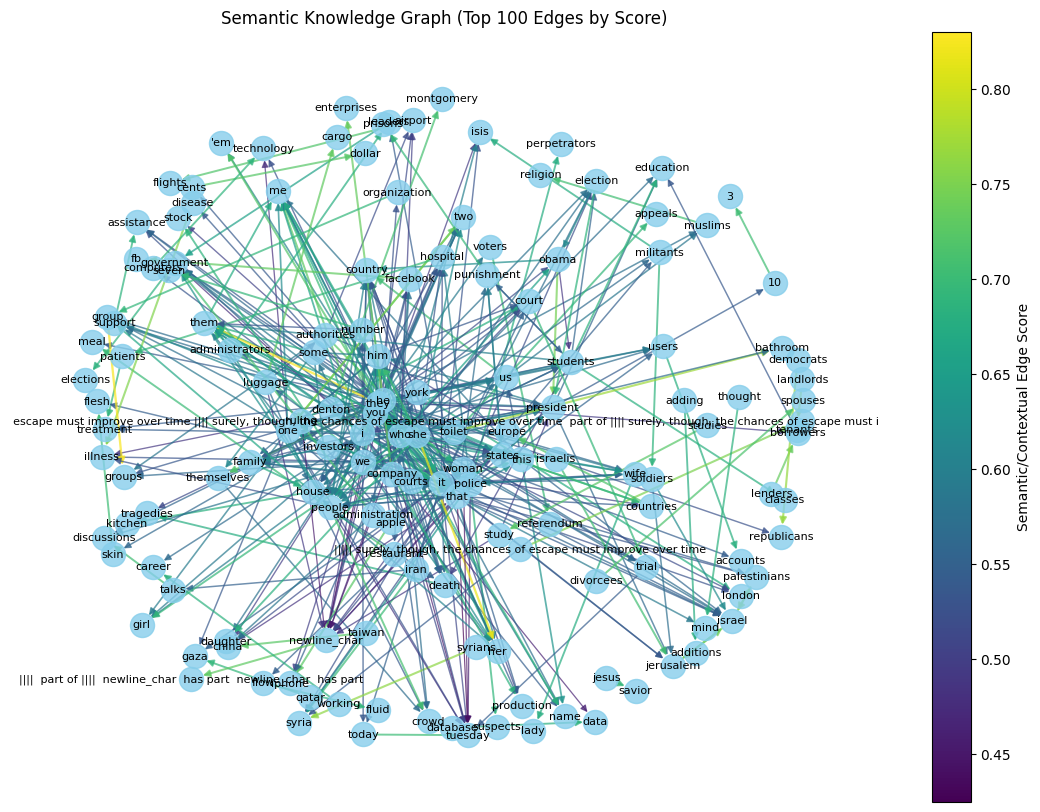

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors


graphml_path = "/content/drive/MyDrive/96517/knowledge_graph_enhanced.graphml"
KG = nx.read_graphml(graphml_path)

print(f"[INFO] Loaded KG: {KG.number_of_nodes()} nodes, {KG.number_of_edges()} edges")

# Use only top edges by score (to avoid clutter)
top_edges = sorted(KG.edges(data=True), key=lambda x: float(x[2].get("score", 0)), reverse=True)[:100]
sub_nodes = set([u for u,v,d in top_edges] + [v for u,v,d in top_edges])
subgraph = KG.subgraph(sub_nodes)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=0.5, seed=42)

# Node styling
nx.draw_networkx_nodes(subgraph, pos, node_size=300, node_color="skyblue", alpha=0.8)

# Edge styling with semantic score
scores = [float(d.get("score", 0)) for u,v,d in subgraph.edges(data=True)]

# Normalize scores to the range [0, 1] for the colormap
norm = colors.Normalize(vmin=min(scores), vmax=max(scores))
cmap = cm.viridis
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(scores)


edges = nx.draw_networkx_edges(
    subgraph, pos,
    edge_color=scores,
    edge_cmap=cmap,  # color by score
    width=[2*s for s in scores],  # thickness by score
    alpha=0.7
)

# Labels
nx.draw_networkx_labels(subgraph, pos, font_size=8, font_color="black")

# Colorbar for scores
cbar = plt.colorbar(mappable, ax=plt.gca())
cbar.set_label("Semantic/Contextual Edge Score")

plt.title("Semantic Knowledge Graph (Top 100 Edges by Score)")
plt.axis("off")
plt.show()

# Hybrid Summary Generation

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize, ne_chunk
from nltk.tree import Tree
resources = ["punkt", "punkt_tab", "maxent_ne_chunker", "words", "averaged_perceptron_tagger","maxent_ne_chunker_tab","averaged_perceptron_tagger_eng"]
for r in resources:
    nltk.download(r)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
import os
import re
import networkx as nx
import torch
from transformers import pipeline

In [ ]:
def load_knowledge_graph(graphml_path):
    if not os.path.exists(graphml_path):
        raise FileNotFoundError(f"File not found: {graphml_path}")
    KG = nx.read_graphml(graphml_path)
    print("[INFO] Knowledge Graph loaded successfully.")
    print(f"[INFO] Number of nodes: {KG.number_of_nodes()}")
    print(f"[INFO] Number of edges: {KG.number_of_edges()}")
    return KG


In [ ]:
PRONOUNS = {
    'he','she','it','they','we','i','you','him','her','them','us','me',
    'that','this','what','which','who','whom','whose','where','there','their'
}

In [ ]:
def is_meaningful_phrase(phrase):
    tokens = re.findall(r'\b[a-zA-Z]+\b', phrase.lower())
    non_pronouns = [t for t in tokens if t not in PRONOUNS]
    return len(non_pronouns) >= 2

def extract_salient_info_from_kg_filtered(KG, top_k=25):
    edges = list(KG.edges(data=True))
    edges = sorted(edges, key=lambda x: float(x[2].get('weight', 0)), reverse=True)

    salient_phrases = []
    for u, v, d in edges:
        relation = d.get('relation', 'related_to')
        phrase = f"{u} {relation} {v}".replace('_', ' ')
        if is_meaningful_phrase(phrase):
            salient_phrases.append(phrase)
        if len(salient_phrases) >= top_k:
            break

    print("\n[INFO] Extracted salient info from KG:")
    for p in salient_phrases:
        print(p)
    return salient_phrases


In [ ]:
def generate_prompt(salient_phrases):
    joined = "\n".join(salient_phrases)
    prompt = (
        "Summarize the following factual information extracted from multiple documents "
        "into a coherent, concise summary paragraph:\n"
        f"{joined}\n\nSummary:"
    )
    print("\n[INFO] Generated prompt:\n", prompt)
    return prompt


In [ ]:
def run_summarization(prompt, max_new_tokens=150):
    device = 0 if torch.cuda.is_available() else -1
    print(f"\n[INFO] Device set to use {'cuda:0' if device == 0 else 'cpu'}")

    summarizer = pipeline(
        "text2text-generation",
        model="google/flan-t5-large",  # lightweight, free Colab-friendly model
        device=device
    )

    summary_output = summarizer(prompt, max_new_tokens=max_new_tokens, do_sample=False)
    summary_text = summary_output[0]["generated_text"].strip()

    # Basic cleanup (optional)
    summary_text = re.sub(r'\s+', ' ', summary_text)
    print("\n[INFO] Generated Summary:\n", summary_text)
    return summary_text


In [ ]:
graphml_path = "/content/drive/MyDrive/96517/knowledge_graph_enhanced.graphml"

KG = load_knowledge_graph(graphml_path)
salient_phrases = extract_salient_info_from_kg_filtered(KG, top_k=25)
if not salient_phrases:
    print("[WARN] No meaningful edges found for summarization.")

prompt = generate_prompt(salient_phrases)
summary = run_summarization(prompt)


[INFO] Knowledge Graph loaded successfully.
[INFO] Number of nodes: 12603
[INFO] Number of edges: 8693

[INFO] Extracted salient info from KG:
aftermath hide tuesday
blm work center
you have history
they feel themselves
what continue luggage
you add applications
he stick life
he say time
it make time
who paper people
they recognise time
story continue newline char
obama walk denver
i ’m tweet
i see things
he try company
he add country
it help life
it join israel
it say jerusalem
that say wednesday
protests hold march
palestinians say israel
bird know deficit
you seem content

[INFO] Generated prompt:
 Summarize the following factual information extracted from multiple documents into a coherent, concise summary paragraph:
aftermath hide tuesday
blm work center
you have history
they feel themselves
what continue luggage
you add applications
he stick life
he say time
it make time
who paper people
they recognise time
story continue newline char
obama walk denver
i ’m tweet
i see things
he 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu



[INFO] Generated Summary:
 you have history they feel themselves what continue luggage you add applications he stick life he say time it make time who paper people they recognise time story continue newline char obama walk denver i ’m tweet i see things he try company he add country it help life it join israel it say jerusalem that say wednesday protests hold march palestinians say israel bird know deficit you seem content


# Optimization of Summarization Models

In [ ]:
pip install -U bitsandbytes

In [ ]:
import os
import re
import pandas as pd
import networkx as nx
import torch
from transformers import (
    pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from datasets import Dataset

In [ ]:
def load_knowledge_graph(graphml_path):
    if not os.path.exists(graphml_path):
        raise FileNotFoundError(f"File not found: {graphml_path}")
    KG = nx.read_graphml(graphml_path)
    print(f"[INFO] Knowledge Graph loaded ({KG.number_of_nodes()} nodes, {KG.number_of_edges()} edges)")
    return KG

PRONOUNS = {
    'he','she','it','they','we','i','you','him','her','them','us','me',
    'that','this','what','which','who','whom','whose','where','there','their'
}

In [ ]:
def is_meaningful_phrase(phrase):
    tokens = re.findall(r'\b[a-zA-Z]+\b', phrase.lower())
    return len([t for t in tokens if t not in PRONOUNS]) >= 2

def extract_salient_info_from_kg_filtered(KG, top_k=25):
    edges = sorted(KG.edges(data=True), key=lambda x: float(x[2].get('weight', 0)), reverse=True)
    phrases = []
    for u, v, d in edges:
        phrase = f"{u} {d.get('relation','related_to')} {v}".replace('_',' ')
        if is_meaningful_phrase(phrase):
            phrases.append(phrase)
        if len(phrases) >= top_k:
            break
    print(f"[INFO] Extracted {len(phrases)} salient KG relations.")
    return phrases

In [ ]:
def build_training_data(csv_path, KG, top_k=25, max_docs=200):
    df = pd.read_csv(csv_path)
    text_col = [c for c in df.columns if any(x in c.lower() for x in ["text","content","document"])]
    if not text_col:
        raise ValueError("No text/content column found.")
    docs = df[text_col[0]].dropna().tolist()[:max_docs]
    salient_phrases = extract_salient_info_from_kg_filtered(KG, top_k)

    dataset = []
    for doc in docs:
        doc_snip = " ".join(doc.split()[:200])  # limit length
        prompt = (
            "Summarize the following document and integrate related facts:\n"
            f"{doc_snip}\n\n[Knowledge Graph Facts]\n"
            + "\n".join(salient_phrases)
        )
        target = " ".join(doc_snip.split()[:100])  # pseudo-summary target
        dataset.append({"input_text": prompt, "target_text": target})

    print(f"[INFO] Prepared {len(dataset)} training samples for fine-tuning.")
    return dataset

In [ ]:
def fine_tune_model(base_model, training_data, output_dir):
    print("\n[INFO] Starting LoRA fine-tuning...")
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForSeq2SeqLM.from_pretrained(base_model)

    lora_cfg = LoraConfig(
        r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="SEQ_2_SEQ_LM"
    )
    model = get_peft_model(model, lora_cfg)

    dataset = Dataset.from_list(training_data)

    def preprocess(batch):
        inputs = tokenizer(batch["input_text"], truncation=True, padding="max_length", max_length=512)
        targets = tokenizer(batch["target_text"], truncation=True, padding="max_length", max_length=128)
        inputs["labels"] = targets["input_ids"]
        return inputs

    dataset = dataset.map(preprocess, batched=True)
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"[INFO] Fine-tuned model saved to {output_dir}")
    return output_dir

In [ ]:
graphml_path = "/content/drive/MyDrive/96517/knowledge_graph_enhanced.graphml"
csv_path = "/content/drive/MyDrive/96517/info_extracted.csv"
base_model = "google/flan-t5-large"
output_dir = "/content/drive/MyDrive/96517/fine_tuned_model_opti"

KG = load_knowledge_graph(graphml_path)
training_data = build_training_data(csv_path, KG, top_k=25, max_docs=200)
fine_tuned_dir = fine_tune_model(base_model, training_data, output_dir)


print("\n completed successfully.")
print(f"Fine-tuned model path: {fine_tuned_dir}")

[INFO] Knowledge Graph loaded (12603 nodes, 8693 edges)
[INFO] Extracted 25 salient KG relations.
[INFO] Prepared 150 training samples for fine-tuning.

[INFO] Starting LoRA fine-tuning...


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

[INFO] Fine-tuned model saved to /content/drive/MyDrive/96517/fine_tuned_model_opti

 completed successfully.
Fine-tuned model path: /content/drive/MyDrive/96517/fine_tuned_model_opti


# Evaluation

In [47]:
import pandas as pd
import torch, textstat
from transformers import pipeline
from evaluate import load

In [48]:
fine_tuned_dir = "/content/drive/MyDrive/96517/fine_tuned_model_opti"
csv_path = "/content/drive/MyDrive/96517/info_extracted.csv"
device = 0 if torch.cuda.is_available() else -1

In [49]:
print("[INFO] Loading fine-tuned model...")
summarizer = pipeline("text2text-generation", model=fine_tuned_dir, device=device)

[INFO] Loading fine-tuned model...


Device set to use cpu


In [50]:
df = pd.read_csv(csv_path)
text_col = [c for c in df.columns if any(x in c.lower() for x in ["text","content","document"])][0]
docs = df[text_col].dropna().head(5).tolist()

In [51]:
print("[INFO] Generating summaries...")
generated, refs = [], []
for doc in docs:
    prompt = "Summarize:\n" + " ".join(doc.split()[:250])
    summary = summarizer(prompt, max_new_tokens=120, do_sample=False)[0]["generated_text"]
    generated.append(summary)
    refs.append(" ".join(doc.split()[:120]))

[INFO] Generating summaries...


In [52]:
print("[INFO] Evaluating summaries...")
rouge = load("rouge")
bert = load("bertscore")

rouge_res = rouge.compute(predictions=generated, references=refs)
bert_res = bert.compute(predictions=generated, references=refs, lang="en")
flesch_scores = [textstat.flesch_reading_ease(s) for s in generated]


[INFO] Evaluating summaries...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [53]:
print("\n=== AVERAGE METRICS ===")
print(f"ROUGE-1: {rouge_res['rouge1']:.3f}")
print(f"ROUGE-2: {rouge_res['rouge2']:.3f}")
print(f"ROUGE-L: {rouge_res['rougeL']:.3f}")
print(f"BERTScore F1: {sum(bert_res['f1'])/len(bert_res['f1']):.3f}")
print(f"Avg Flesch Reading Ease: {sum(flesch_scores)/len(flesch_scores):.2f}")

print("\nevaluation completed.")


=== AVERAGE METRICS ===
ROUGE-1: 0.516
ROUGE-2: 0.448
ROUGE-L: 0.477
BERTScore F1: 0.884
Avg Flesch Reading Ease: 59.44

evaluation completed.


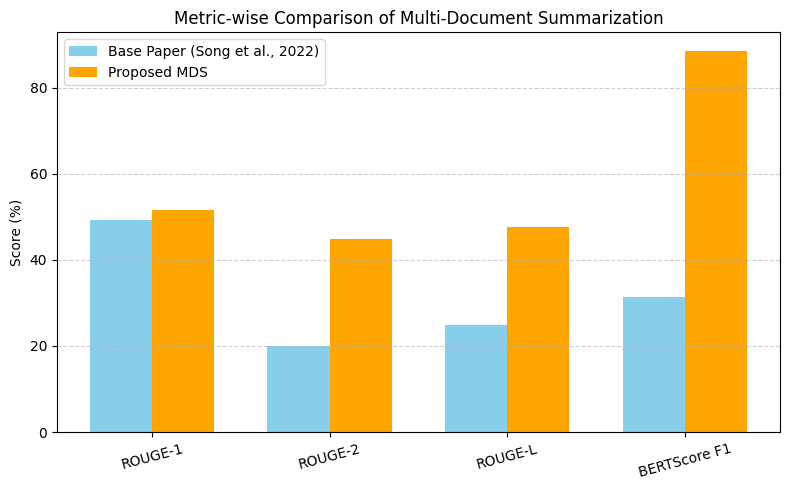

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

base_scores = {
    "ROUGE-1": 49.27,
    "ROUGE-2": 19.96,
    "ROUGE-L": 24.76,
    "BERTScore F1": 31.33
}

proposed_scores = {
    "ROUGE-1": 51.6,
    "ROUGE-2": 44.8,
    "ROUGE-L": 47.7,
    "BERTScore F1": 88.4
}

def avg_score(scores):
    return np.mean(list(scores.values()))

avg_base = avg_score(base_scores)
avg_prop = avg_score(proposed_scores)
improvement = ((avg_prop - avg_base) / avg_base) * 100


metrics = list(base_scores.keys())
base_vals = list(base_scores.values())
prop_vals = list(proposed_scores.values())

x = np.arange(len(metrics))
width = 0.35


plt.figure(figsize=(8,5))
plt.bar(x - width/2, base_vals, width, label='Base Paper (Song et al., 2022)', color='skyblue')
plt.bar(x + width/2, prop_vals, width, label='Proposed MDS', color='orange')

plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score (%)")
plt.title("Metric-wise Comparison of Multi-Document Summarization")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Base Avg: 31.33 | Proposed Avg: 58.13 | Improvement: 85.53%


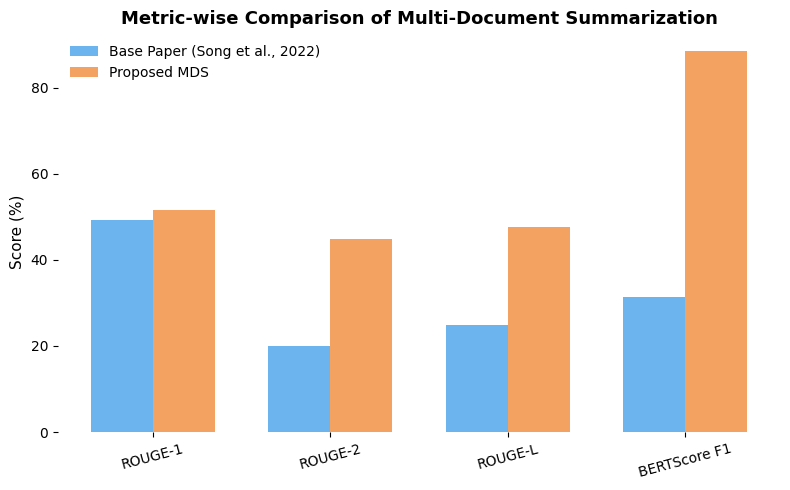

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Base paper scores (Song et al., 2022)
base_scores = {
    "ROUGE-1": 49.27,
    "ROUGE-2": 19.96,
    "ROUGE-L": 24.76,
    "BERTScore F1": 31.33
}

# Proposed system scores
proposed_scores = {
    "ROUGE-1": 51.6,
    "ROUGE-2": 44.8,
    "ROUGE-L": 47.7,
    "BERTScore F1": 88.4
}

# Compute averages and improvement
def avg_score(scores):
    return np.mean(list(scores.values()))

avg_base = avg_score(base_scores)
avg_prop = avg_score(proposed_scores)
improvement = ((avg_prop - avg_base) / avg_base) * 100

print(f"Base Avg: {avg_base:.2f} | Proposed Avg: {avg_prop:.2f} | Improvement: {improvement:.2f}%")

# Prepare data
metrics = list(base_scores.keys())
base_vals = list(base_scores.values())
prop_vals = list(proposed_scores.values())

x = np.arange(len(metrics))
width = 0.35

# Plot without background grid lines
plt.figure(figsize=(8,5))
plt.bar(x - width/2, base_vals, width, label='Base Paper (Song et al., 2022)', color='#6cb4ee')
plt.bar(x + width/2, prop_vals, width, label='Proposed MDS', color='#f4a261')

plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score (%)", fontsize=11)
plt.title("Metric-wise Comparison of Multi-Document Summarization", fontsize=13, fontweight='bold')
plt.legend(frameon=False)
plt.box(False)  # Removes border box
plt.tight_layout()
plt.show()
